# 31회차 기출문제


## 문제 1

**Data description**

개인의 헬스케어 데이터를 활용하여 비만 수준을 예측하는 문제입니다.

-   **Gender** : 성별

-   **Age** : 나이

-   **Height** : 키

-   **Weight** : 몸무게

-   **family_history_with_overweight** : 가족 중 과체중인 사람이 있는지 여부

-   **FAVC** : 고칼로리 식품을 자주 섭취하는지 여부

-   **FCVC** : 채소 섭취 빈도

-   **NCP** : 식사 횟수

-   **CAEC** : 간식 섭취 빈도

-   **SMOKE** : 흡연 여부

-   **CH20** : 물 섭취 양

-   **SCC** : 섭취 칼로리를 모니터링하는지 여부

-   **FAF** : 운동 빈도

-   **TUE** : 전자제품(휴대폰, TV, 비디오게임 등) 사용 빈도

-   **CALC** : 알코올 섭취 빈도

-   **MTRANS** : 주로 이용하는 교통 수단

-   **NObeyesdad** : 비만 수준

    -   overweight_level_i : 과체중 수준 i
    -   obesity_type_i : 비만 유형 i
    -   obesity_type_ii : 비만 유형 ii
    -   obesity_type_iii : 비만 유형 iii

1.  **데이터 분포를 살펴보고 특성을 기술하시오.**

In [1]:
#| warning: false

import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dat = pd.read_csv('problem1.csv')

In [3]:
dat.head(3)

,Unnamed: 0,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0,4,male,27,1.80,87,no,no,always,3,sometimes,no,between 1 and 2 l,no,2 to 4,0 to 2,frequently,walking,overweight_level_i,26.851852
1,1,11,male,26,1.85,105,yes,yes,always,3,frequently,no,more than 2 l,no,2 to 4,>5,sometimes,public_transportation,obesity_type_i,30.679328
2,2,14,male,41,1.80,99,no,yes,sometimes,3,sometimes,no,between 1 and 2 l,no,2 to 4,3 to 5,frequently,automobile,obesity_type_i,30.555556


In [4]:
dat = dat.iloc[:, 2:]

index, id 칼럼의 경우 데이터에 정보량이 없으므로 삭제한다.

In [5]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          1262 non-null   object 
 1   Age                             1262 non-null   int64  
 2   Height                          1262 non-null   float64
 3   Weight                          1262 non-null   int64  
 4   family_history_with_overweight  1262 non-null   object 
 5   FAVC                            1262 non-null   object 
 6   FCVC                            1262 non-null   object 
 7   NCP                             1262 non-null   int64  
 8   CAEC                            1262 non-null   object 
 9   SMOKE                           1262 non-null   object 
 10  CH2O                            1262 non-null   object 
 11  SCC                             1259 non-null   object 
 12  FAF                             12

In [6]:
dat.isnull().mean() * 100

Gender                            0.000000
Age                               0.000000
Height                            0.000000
Weight                            0.000000
family_history_with_overweight    0.000000
FAVC                              0.000000
FCVC                              0.000000
NCP                               0.000000
CAEC                              0.000000
SMOKE                             0.000000
CH2O                              0.000000
SCC                               0.237718
FAF                               0.000000
TUE                               0.000000
CALC                              0.000000
MTRANS                            0.000000
NObeyesdad                        0.000000
BMI                               0.000000
dtype: float64

SCC(섭취 칼로리를 모니터링하는지 여부) 변수에 결측치가 약 0.24% 존재한다.

**연속형 변수 분포 확인**

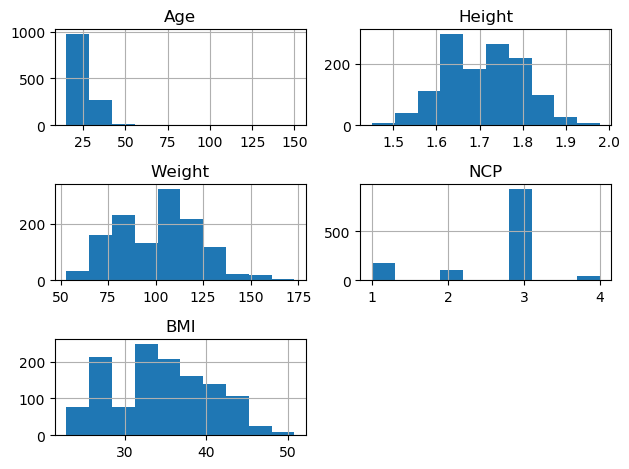

In [7]:
dat.hist();
plt.tight_layout();
plt.show();

-   age(나이)의 경우 15 \~ 40 사이에 대부분 분포되어 있으며, 나이가 150인 이상치가 존재하는 것을 확인할 수 있다.

-   bmi의 경우 이봉분포 형태로 22 \~ 30 사이의 그룹1, 30 \~ 50 사이에 그룹2로 나눠지는 것을 확인할 수 있다.

-   ncp(식사횟수)의 경우 3회가 가장 많으며, 1\>2\>4회 순인 것으로 나타났다.

**범주형 변수 분포 확인**

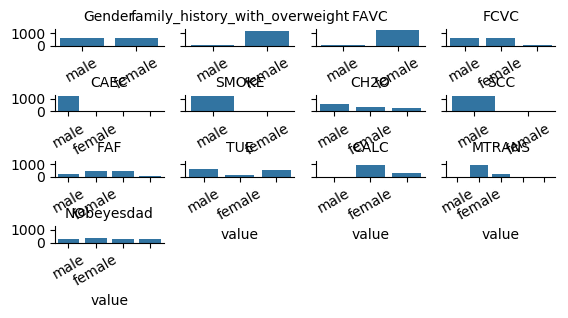

In [8]:
cat_columns = dat.select_dtypes('object').columns
long_dat = pd.melt(dat,
        value_vars = cat_columns, 
        var_name = 'cat_variable', 
        value_name = 'value', 
        ignore_index = False)
        
long_dat.head(2)

g = sns.FacetGrid(long_dat, 
                  col ='cat_variable', 
                  col_wrap=4, # grid(행, 열)에서 열 개수 
                  height=0.7, # 그래프 높이 조절 
                  aspect=2, # 그래프 패널의 비율 조절(가로 길이를 세로 길이의 2배로 조절) 
                  sharex = False) # grid(행, 열) 그래프별 축을 다르게 표시
g.map(sns.countplot, 'value');
g.set_titles('{col_name}'); # 그래프 타이틀 설정
g.set_xticklabels(rotation=30);  # x축 레이블 45도 회전
plt.subplots_adjust(top=0.9, hspace = 3, wspace = 0.2); # hspace : 서브 플랏 행 간 간격 조절   
plt.show();

-   family_history_with_overweight(가족 중 과체중인 사람이 있는지 여부)의 경우 가족 중 과체중인 사람이 있는 경우가 약 92%로 가장 많았다.

-   favc(고칼로리 식품을 자주 섭취하는지 여부)의 경우 고칼로리 식품을 자주 섭취하는 경우가 전체의 약 96%로 가장 많았다.

-   fcvc(채소 섭취 빈도)의 경우 채소 섭취를 때때로, 자주 섭취한다는 응답이 전체의 약 96%로 가장 많았다.

-   caec(간식섭취빈도)의 경우 때때로 섭취한다는 응답이 전체의 약 94%로 가장 많았다.

-   smoke(흡연 여부)의 경우 비흡연으로 응답한 경우가 가장 많았다.

-   ch2o(물섭취 양)의 경우 1\~ 2L를 섭취하는 경우가 가장 많았다.

-   scc(섭취 칼로리를 모니터링하는지 여부)의 경우 섭취칼로리를 모니터링안한다고 응답한 경우가 가장 많았다.

-   faf(운동빈도)의 경우 0회 or 1\~2회 운동한다고 응답한 경우가 가장 많았다.

-   tue(전자제품 사용빈도)의 경우 0\~2회 활용하는 경우가 가장 많았다.

-   calc(알코올 섭취빈도)의 경우 때때로 섭취한다고 응답한 경우가 가장 많았다.

-   mtrans(주로 이용하는 교통수단)의 경우 대중교통을 이용한다는 응답이 가장 많았다.

-   n_obeyesdad(비만 수준)의 경우 과체중 수준, 비만 유형별로 고르게 분포하는 것을 확인할 수 있다.

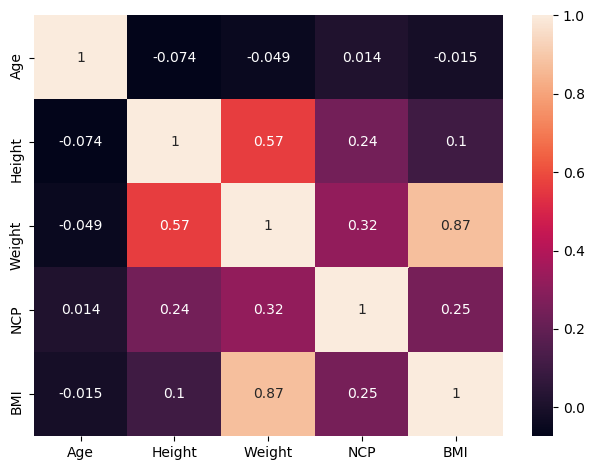

In [9]:
corr = dat.select_dtypes('number').corr()
sns.heatmap(corr, annot = True);
plt.tight_layout();
plt.show();

-   weight와 bmi의 경우 상관계수 = 0.87로, 매우 높은 양의 상관관계를 보인다.

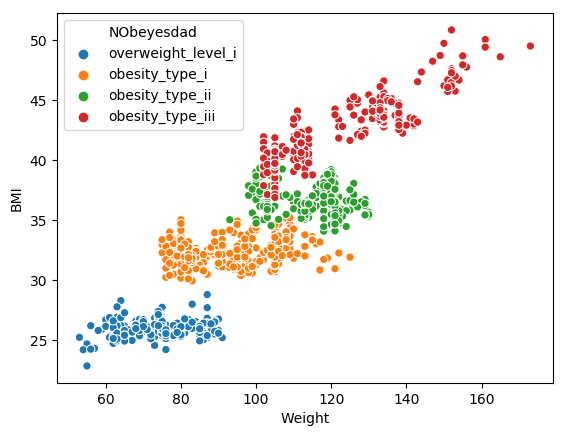

In [10]:
sns.scatterplot(data = dat, x='Weight', y='BMI', hue='NObeyesdad');
plt.show();

-   bmi와 weight, n_obeyesdad의 관계를 보면 bmi 값에 따라 n_obeyesdad(비만 수준)이 그룹핑되므로, n_obeyesdad(비만 수준)를 예측하는데 bmi는 중요한 변수인 것을 확인할 수 있다.

2.  **데이터 전처리 기법 2가지를 기술하고, 해당 기법이 어떤 효과가 있는지 설명하시오.**

**결측치 처리**

먼저 결측치를 대치하기 전에 학습 데이터와 검증 데이터를 분할한다. 학습 데이터와 검증 데이터를 사전에 분할하는 이유는 최종 모형 평가에 활용되는 검증 데이터의 정보가 데이터 전처리 과정에서 활용되는 것을 방지 하기 위함이다.

In [11]:
y = dat.NObeyesdad
X = dat.drop(['NObeyesdad'], axis = 1)

from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.3, random_state = 0)

print('train 데이터 :', len(train_X), 'test 데이터 :', len(test_X))

train 데이터 : 883 test 데이터 : 379


결측치를 처리하는 방법은 크게 대표값을 이용하는 방법과 모델을 이용하는 방법이 있다. 대표값을 이용한 방법 중 대표적으로 최빈값 대치법이 있다. 최빈값 대치법은 해당 변수의 대표값인 최빈값으로 결측치를 대치하는 방법으로 단점으로는 결측치 수가 많을 때 분포가 왜곡되는 문제가 있을 수 있다. 결측치의 비율이 높지 않으므로, 최빈값 대치법을 이용한다.

In [12]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline

cat_columns = train_X.select_dtypes('object').columns
impute_preprocess = make_pipeline(
    SimpleImputer(missing_values = np.nan, strategy='most_frequent')
)

preprocess = ColumnTransformer(
    [("imputation", impute_preprocess, cat_columns)]
)

imp_train_X = preprocess.fit_transform(train_X)
imp_train_X = pd.DataFrame(imp_train_X, columns = cat_columns)
imp_train_X.isna().sum()

Gender                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
dtype: int64

scc변수의 결측치가 모두 대치된 것을 확인할 수 있다.

2.  **이상치 처리**

EDA 결과 age 변수에 age = 150으로 이상치가 존재하는 것을 확인했다. 최고령 나이는 약 120세로, age = 150인 경우는 이상치로 볼 수 있다. 따라서 이상치를 제거한다.

In [13]:
filtered_train = train_X.Age != 150
filtered_test = test_X.Age != 150
train_X = train_X.loc[filtered_train, ]
test_X = test_X.loc[filtered_test, ]

train_y = train_y.loc[filtered_train]
test_y = test_y.loc[filtered_test]

3.  **주어진 데이터를 확인하고, 파생변수를 1개 생성하시오.**

각 n_obeyesdad별 bmi 분포를 확인한다.

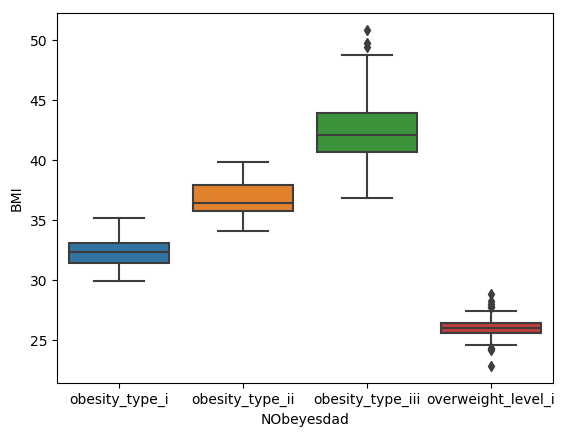

In [14]:
train = pd.concat([train_X, train_y], axis = 1)
sns.boxplot(x = "NObeyesdad", y = "BMI", data = train);
plt.show();

In [15]:
pd.set_option('display.max_columns', None)  # 모든 열 출력
summary_stats = (
    train.groupby('NObeyesdad')['BMI']
    .agg(
        min = pd.Series.min,
        q1= lambda x: x.quantile(0.25),
        mean = pd.Series.mean,
        median = pd.Series.median,
        q3 = lambda x: x.quantile(0.75),
        max = pd.Series.max
    )
)

print(summary_stats)

                          min         q1       mean     median         q3  \
NObeyesdad                                                                  
obesity_type_i      29.911958  31.420167  32.306040  32.270788  33.057851   
obesity_type_ii     34.048509  35.739524  36.702061  36.409691  37.850764   
obesity_type_iii    36.774400  40.640359  42.355936  42.016688  43.877089   
overweight_level_i  22.826739  25.564954  25.989286  25.992439  26.395803   

                          max  
NObeyesdad                     
obesity_type_i      35.171095  
obesity_type_ii     39.786652  
obesity_type_iii    50.811753  
overweight_level_i  28.769607  


overweight_level_i와 obesity_type_i는 bmi = 28.4를 기준으로 완벽하게 나눠진다. obesity_type_i과 obesity_type_ii는 bmi = 35.3, obesity_type_ii과 obesity_type_iii는 bmi = 39.9를 기준으로 일부 오분류가 있지만 거의 대부분 나눠지는 것을 확인할 수 있다. 따라서 타겟 변수인 n_obeyesdad와 관련이 높은 bmi를 활용하여 bmi_group 파생변수를 생성한다.

In [16]:
bins = [0, 28.4, 35.3, 39.9, 51]  # 구간 설정
labels = ['bin1', 'bin2', 'bin3', 'bin4']  # 레이블 설정

train_X['bmi_binned'] = pd.cut(train_X['BMI'], bins=bins, labels=labels)
test_X['bmi_binned'] = pd.cut(test_X['BMI'], bins=bins, labels=labels)

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder

cat_columns = train_X.select_dtypes(['object', 'category']).columns

cat_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # 결측치를 가장 빈도가 높은 값으로 대체
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocess = ColumnTransformer(
    transformers=[
        ('cat', cat_preprocess, cat_columns)
    ],
    remainder='passthrough'
)


from sklearn import set_config
set_config(display="diagram")

preprocess

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'bmi_binned'],
      dtype='object'))])

4.  **앙상블을 제외한 분류 알고리즘 3개를 선정하고, 그 이유를 기술하시오.**

-   Decision tree

Decision tree는 나무구조를 활용한 의사결정 규칙을 통해서 분류 혹은 예측을 수행하는 방법이다. 범주형 변수의 경우 gini index, cross entropy, 연속형 변수의 경우 SSE를 활용하여, 데이터에 맞는 적절한 분할 기준을 구축하여 의사결정나무를 생성한다. 단일의사결정나무의 경우 시각화를 통해 해석의 장점이 있다.

-   Multi-Layer Perceptron(MLP)

MLP는 인공 신경망의 기본 구조로, 여러 층, 노드로 구성된 비선형 모델이다. 각 노드는 가중치를 적용한 후 비선형 활성화 함수를 적용하여 데이터의 복잡한 패턴을 학습한다. 층의 개수, 노드의 개수에 따라 모델 성능 측면에서의 장점이 있다.

-   Support vector machine(SVM)

SVM은 마진(margin)을 최대화하는 초평면을 찾는 알고리즘이다. 이진 분류 문제에서 마진은 각 범주 간 관측치 사이의 최단 거리를 의미한다. SVM의 경우 커널 트릭을 활용하여 비선형 결정 경계를 쉽게 만들 수 있는 장점이 있다.

Decision tree는 모형 해석력 측면에서 장점이 있으며, SVM, MLP의 경우 모형 성능 측면에서 장점이 존재한다. 따라서 세 모형을 선택하였다.

5.  **하이퍼파라미터 튜닝을 실시하고, Precision, Recall을 계산하시오.**

모델 튜닝은 파라미터의 범위를 제한하여 진행하였으며, 5-fold 교차검증을 통해 validation 데이터를 여러번 생성 후 적합하여, 하이퍼파라미터별 모형 성능을 교차 검증하였다.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

dt_pipe = Pipeline(
    [
        ("preprocess", preprocess),
        ("classifier", DecisionTreeClassifier())
    ]
)

mlp_pipe = Pipeline(
    [
        ("preprocess", preprocess),
        ("classifier", MLPClassifier()) # defaut : 'ovr'
    ]
)

svm_pipe = Pipeline(
    [
        ("preprocess", preprocess),
        ("classifier", SVC(probability=True)) # defaut : 'ovr'
    ]
)

-   Decision tree

cp 파라미터는 가지치기를 통해 decision tree의 크기를 조정하는 파라미터로, 모델의 SSE와 terminal node의 수 간의 trade off를 조정하는 파라미터이다. 0 \< cp \< 1 사이로 0.1 간격으로 튜닝을 진행하였다.

In [18]:
from sklearn.metrics import make_scorer, precision_score, recall_score

scoring = {
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro')
}

In [19]:
from sklearn.model_selection import GridSearchCV
decisiontree_param = {'classifier__ccp_alpha': np.arange(0.1, 1, 0.1)}
decisiontree_search = GridSearchCV(estimator = dt_pipe, 
                      param_grid = decisiontree_param, 
                      cv = 5,
                      scoring = scoring,  
                      refit = 'precision'
                      )
decisiontree_search.fit(train_X, train_y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'bmi_binned'],
      dtype='object'))])),
                                       ('classifier',
                                        DecisionTreeClassifier())]),
             param_grid={'classifier__ccp_alpha': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
             refit='precision',
             scoring={'precision': make_scorer(precision_score, average=macro),
                      'recall': make_scorer(recall_score, average=macro)})

-   MLP

learning_rate 파라미터는 경사하강법으로 모델을 업데이트할 때 학습률을 조절하는 파라미터이다. 적절한 범위에서 learning_rate를 조절한다.

In [20]:
MLP_param = {'classifier__learning_rate_init': np.arange(0.01, 0.2, 0.02)}

MLP_search = GridSearchCV(estimator = mlp_pipe, 
                      param_grid = MLP_param, 
                      #cv = cv,
                      cv = 5, # KFold 5
                      scoring = scoring,  
                      refit = 'precision'
                      )
MLP_search.fit(train_X, train_y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'bmi_binned'],
      dtype='object'))])),
                                       ('classifier', MLPClassifier())]),
             param_grid={'classifier__learning_rate_init': array([0.01, 0.03, 0.05, 0.07, 0.09, 0.11, 0.13, 0.15, 0.17, 0.19])},
             refit='precision',
             scoring={'precision': make_scorer(precision_score, average=macro),
                      'recall': make_scorer(recall_score, average=macro)})

-   SVM

C 파라미터는 SVM의 오분류율 허용 정도를 조절하여 과적합을 조절하는 파라미터이다. 적절한 범위에서 C 파라미터를 조절한다.

In [21]:
SVC_param = {'classifier__C': np.arange(1, 100, 20)}

SVC_search = GridSearchCV(estimator = svm_pipe, 
                      param_grid = SVC_param, 
                      #cv = cv,
                      cv = 5, # KFold 5
                      scoring = scoring,  
                      refit = 'precision')
SVC_search.fit(train_X, train_y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'bmi_binned'],
      dtype='object'))])),
                                       ('classifier', SVC(probability=True))]),
             param_grid={'classifier__C': array([ 1, 21, 41, 61, 81])},
             refit='precision',
             scoring={'precision': make_scorer(precision_score, average=macro),
                      'recall': make_scorer(recall_score, average=macro)})

In [22]:
from sklearn.metrics import classification_report
pred1 = decisiontree_search.predict(test_X)
print(classification_report(test_y, pred1))

pred2 = MLP_search.predict(test_X)
print(classification_report(test_y, pred2))

pred3 = SVC_search.predict(test_X)
print(classification_report(test_y, pred3))

                    precision    recall  f1-score   support

    obesity_type_i       0.96      0.98      0.97       111
   obesity_type_ii       0.98      0.94      0.96        89
  obesity_type_iii       0.98      0.99      0.99       105
overweight_level_i       1.00      1.00      1.00        72

          accuracy                           0.98       377
         macro avg       0.98      0.98      0.98       377
      weighted avg       0.98      0.98      0.98       377

                    precision    recall  f1-score   support

    obesity_type_i       0.95      0.92      0.94       111
   obesity_type_ii       0.89      0.94      0.92        89
  obesity_type_iii       1.00      0.93      0.97       105
overweight_level_i       0.92      1.00      0.96        72

          accuracy                           0.94       377
         macro avg       0.94      0.95      0.94       377
      weighted avg       0.95      0.94      0.94       377

                    precision    r

SVM 모델의 성능이 가장 우수하다.

6.  **위의 결과에 대해서 SOFT VOTING 기법을 적용하고 이전 결과와 비교하시오.**

In [23]:
from sklearn.ensemble import VotingClassifier

voting_soft = VotingClassifier(estimators=[
    ('dt', decisiontree_search),
    ('mlp', MLP_search),
    ('svm', SVC_search)
], voting='soft')

voting_soft.fit(train_X, train_y)

VotingClassifier(estimators=[('dt',
                              GridSearchCV(cv=5,
                                           estimator=Pipeline(steps=[('preprocess',
                                                                      ColumnTransformer(remainder='passthrough',
                                                                                        transformers=[('cat',
                                                                                                       Pipeline(steps=[('imputer',
                                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                                       ('onehot',
                                                                                                                        OneHotEncoder(handle_unknown='ignore'))]),
                                                                                                       Index(['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC',
       'SMO...
                                                                                                       Index(['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'bmi_binned'],
      dtype='object'))])),
                                                                     ('classifier',
                                                                      SVC(probability=True))]),
                                           param_grid={'classifier__C': array([ 1, 21, 41, 61, 81])},
                                           refit='precision',
                                           scoring={'precision': make_scorer(precision_score, average=macro),
                                                    'recall': make_scorer(recall_score, average=macro)}))],
                 voting='soft')

In [24]:
pred4 = voting_soft.predict(test_X)
print(classification_report(test_y, pred4))

                    precision    recall  f1-score   support

    obesity_type_i       0.97      1.00      0.99       111
   obesity_type_ii       0.99      0.97      0.98        89
  obesity_type_iii       1.00      0.99      1.00       105
overweight_level_i       1.00      1.00      1.00        72

          accuracy                           0.99       377
         macro avg       0.99      0.99      0.99       377
      weighted avg       0.99      0.99      0.99       377



단일 모델과 soft voting 모델 간의 성능 차이가 미미하다.

7.  **하나의 모델을 선정하여 Feature importance와 Drop column importance를 활용하여 변수를 선택하시오.**

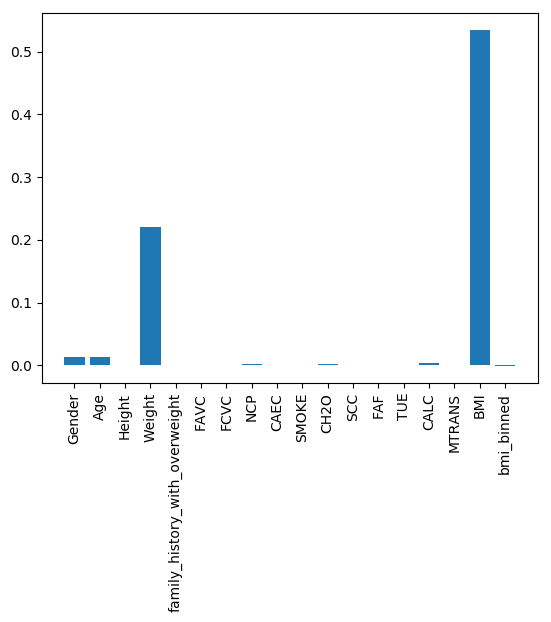

In [25]:
from sklearn.inspection import permutation_importance
feature_importances = permutation_importance(
    SVC_search, train_X, train_y, n_repeats=10, random_state=42
)

import matplotlib.pyplot as plt
features = train_X.columns
importances = feature_importances.importances_mean
plt.bar(features, importances);
plt.xticks(rotation=90);
plt.show();

feature importance의 경우 bmi, weight 칼럼이 변수 중요도가 높은 것으로 나타남

In [26]:
from sklearn.base import clone # 모델 복제 
full_model = clone(SVC_search)
full_model.fit(train_X, train_y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'bmi_binned'],
      dtype='object'))])),
                                       ('classifier', SVC(probability=True))]),
             param_grid={'classifier__C': array([ 1, 21, 41, 61, 81])},
             refit='precision',
             scoring={'precision': make_scorer(precision_score, average=macro),
                      'recall': make_scorer(recall_score, average=macro)})

In [27]:
full_model_score = full_model.score(train_X, train_y)
drop_column_importances = {}

for col in train_X.columns:
    
    temp_X = train_X.drop(columns=[col])
    cat_columns = temp_X.select_dtypes(['object', 'category']).columns
    
    preprocess = ColumnTransformer([('cat', cat_preprocess, cat_columns)], remainder='passthrough')
    
    reduce_model = Pipeline(
        [
            ("preprocess", preprocess),
            ("classifier", SVC(probability=True)) 
        ])
    
    reduce_model.fit(temp_X, train_y)
    drop_column_importances[col] = full_model_score - reduce_model.score(temp_X, train_y)
    
dcimp = pd.Series(drop_column_importances)
dci_score = (dcimp - dcimp.min()) / (dcimp.max() - dcimp.min())
dci_score = dci_score.round(2).sort_values(ascending=False)
print(dci_score)

BMI                               1.00
Age                               0.40
bmi_binned                        0.32
Gender                            0.31
CH2O                              0.30
FCVC                              0.30
TUE                               0.29
CALC                              0.29
NCP                               0.29
FAF                               0.28
SCC                               0.28
SMOKE                             0.28
FAVC                              0.28
family_history_with_overweight    0.28
Height                            0.28
MTRANS                            0.28
CAEC                              0.28
Weight                            0.00
dtype: float64


drop column importance의 경우 bmi, age 등의 칼럼이 변수 중요도가 높은 것으로 나타남

## 문제 2

**Data description**

개인의 건강검진 데이터를 활용하여 다음 문제를 해결하시오.

-   **ID**

-   **키**

-   **weight**

-   **생년월일**

-   **건강검진일**

-   **공학여부**

-   **채소섭취정도**

-   **아침식사여부**

-   **일주일운동시간**

-   **수면시간**

-   **성별**

1.  **위 표를 바탕으로 파생변수(적정체중 여부)를 도출하고, 만나이와 파생변수(적정체중 여부)의 빈도표를 산출하시오.**

-   만나이 : (검진날짜 - 생년월일)/365, 소수점 버림

-   BMI : $\frac{몸무게}{키^2}$ (키는 m 기준), 소수점 둘째자리 반올림

|      | 16세         | 17세         |
|------|--------------|--------------|
| 남자 | 17.3 \~ 18.4 | 17.8 \~ 20.4 |
| 여자 | 16.7 \~ 18.7 | 16.7 \~ 18.7 |

: 성별과 만나이에 따른 BMI 기준표(적정 체중 기준)

|      | YES | NO  |
|------|-----|-----|
| 16세 | 00  | 00  |
| 17세 | 00  | 00  |

: 빈도표 예시

In [28]:
dat = pd.read_csv('problem2.csv')

In [29]:
from datetime import datetime

# 생년월일을 날짜형식으로 변환
dat['생년월일'] = pd.to_datetime(dat['생년월일'], format='%Y%m%d')

# 건강검진일의 '_'를 '-'로 대체하고 날짜형식으로 변환
dat['건강검진일'] = dat['건강검진일'].str.replace('_', '')
dat['건강검진일'] = pd.to_datetime(dat['건강검진일'], format='%Y-%m-%d')

# 만나이 계산
dat['만나이'] = ((dat['건강검진일'] - dat['생년월일']).dt.days / 365).astype(int)

# 키를 미터로 변환하여 BMI 계산
dat['키'] = dat['키'] / 100
dat['bmi'] = round(dat['weight'] / (dat['키'] ** 2), 1)

# 아침식사 여부 object로 변환 
dat = dat.astype({'아침식사여부' : 'object', 
                  '공학여부' : 'object'})

In [30]:
dat['f_weight'] = np.where(
    (dat['만나이'] == 16) & (dat['성별'] == '남성') & dat['bmi'].between(17.3, 18.4), 'yes',
    np.where(
        (dat['만나이'] == 17) & (dat['성별'] == '남성') & dat['bmi'].between(17.8, 20.4), 'yes',
        np.where(
            (dat['만나이'] == 16) & (dat['성별'] == '여성') & dat['bmi'].between(16.7, 18.7), 'yes',
            np.where(
                (dat['만나이'] == 17) & (dat['성별'] == '여성') & dat['bmi'].between(16.7, 18.7), 'yes',
                'no'
            )
        )
    )
)

f_table = pd.crosstab(dat['만나이'], dat['f_weight'])

# 결과 출력
print(f_table)

f_weight    no  yes
만나이                
16        2981  134
17        3343  343


파생변수를 만들었으므로, 만나이, bmi, 만나이, weight 변수는 삭제한다.

In [31]:
dat = dat.drop(columns=['만나이', 'bmi', 'weight'])

2.  **파생변수(적정체중 여부)와 기존 변수와의 유의성 확인하시오.**

코드 예시

In [32]:
from scipy.stats import chi2_contingency
table1 = pd.crosstab(dat['f_weight'], dat['성별'])

chi2, p, df, expected = chi2_contingency(table1)
print('statistics :', np.round(chi2, 2), 'p-value :', np.round(p, 2))

N = np.sum(table1.values) 
minimum_dimension = min(table1.shape)-1
Cramer_v = np.sqrt((chi2/N) / minimum_dimension) 
print('Cramer v :', np.round(Cramer_v, 2))

from scipy.stats import ttest_ind
aa1 = dat.loc[dat['f_weight'] == 'yes', '채소섭취정도']
aa2 = dat.loc[dat['f_weight'] == 'no', '채소섭취정도']
ttest_ind(aa1, aa2, equal_var = False)

statistics : 0.13 p-value : 0.71
Cramer v : 0.0


Ttest_indResult(statistic=1.6226855213270701, pvalue=0.10522874403781284)

**범주형 변수 간의 관계**

-   통계적으로 유의한 변수 없음

::: callout-note
통계적으로 유의한 변수 있을 경우 답안 예시 :

독립성 검정 결과 유의 수준 5%에서 p-value = 0.00로 귀무가설을 기각한다. 따라서 Y와 X 간에는 통계적으로 유의미한 관계가 존재한다. cramer’s v = 0로 연관성의 강도는 크지 않다.
:::

범주형 그룹 간 연속형 변수 간의 관계

-   통계적으로 유의한 변수 없음

::: callout-note
통계적으로 유의한 변수 있을 경우 답안 예시 :

welch t-test 결과 유의 수준 5%에서 p-value = 0.02로 귀무가설을 기각한다. 따라서 Y와 X 간에는 통계적으로 유의미한 관계가 존재한다. hedges’ g = -0.14로 약한 연관성이 존재하는 것을 확인할 수 있다.
:::

3.  **Logistic regression과 XGBoost 모형을 적합하시오.**

    **(위 문제에서 통계적으로 유의한 변수를 활용하여) 구문 제거 –\> 문제 수정**

In [33]:
dat = dat.drop(columns=['ID', '키', '생년월일', '건강검진일'])

데이터 전처리 및 모델링 이전에 훈련 데이터와 테스트 데이터를 분할한다. 단순 무작위 샘플링을 통해 훈련 데이터와 테스트 데이터를 7:3으로 분할한다.

In [34]:
y = dat.f_weight
X = dat.drop(['f_weight'], axis = 1)

from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.3, random_state = 0)

print('train 데이터 :', len(train_X), 'test 데이터 :', len(test_X))

train 데이터 : 4760 test 데이터 : 2041


In [35]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import label_binarize

import statsmodels.api as sm
import statsmodels.formula.api as smf

all_X_columns = train_X.columns.to_list()
cols_str = " + ".join(all_X_columns)
train = pd.concat([train_X, train_y], axis = 1)

logit_model = sm.formula.glm(formula = f"f_weight ~ {cols_str}", family=sm.families.Binomial(), data = train).fit()

In [36]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
le = LabelEncoder()
train_y = le.fit_transform(train_y)
test_y = le.transform(test_y)

cat_columns = train_X.select_dtypes('object').columns

cat_preprocess = make_pipeline(
    OneHotEncoder(handle_unknown="ignore", sparse=False)
)

preprocess = ColumnTransformer([('cat', cat_preprocess, cat_columns)], remainder='passthrough')

pipe_xgb = Pipeline(
    [
        ("preprocess", preprocess),
        ("classifier", xgb.XGBClassifier()) 
    ]
)
pipe_xgb.fit(train_X, train_y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse=False))]),
                                                  Index(['공학여부', '아침식사여부', '성별'], dtype='object'))])),
                ('classifier', XGBClassifier())])

4.  **회귀계수에 대해 오즈비로 해석하고, 통계적 유의성을 확인하시오.**

In [37]:
print(logit_model.summary())

                         Generalized Linear Model Regression Results                         
Dep. Variable:     ['f_weight[no]', 'f_weight[yes]']   No. Observations:                 4760
Model:                                           GLM   Df Residuals:                     4753
Model Family:                               Binomial   Df Model:                            6
Link Function:                                 Logit   Scale:                          1.0000
Method:                                         IRLS   Log-Likelihood:                -1211.7
Date:                               Sun, 06 Jul 2025   Deviance:                       2423.4
Time:                                       21:38:08   Pearson chi2:                 4.76e+03
No. Iterations:                                    6   Pseudo R-squ. (CS):           0.001205
Covariance Type:                           nonrobust                                         
                  coef    std err          z      P>|z|     

-   통계적으로 유의한 회귀계수 없음

::: callout-note
연속형 변수 회귀계수 해석 예시

채소섭취정도가 한 단위 증가하면 적정체중을 갖을 오즈는 $exp(0.049978) \approx 1.05$배 높게 나타난다. 채소섭취결과에 대한 통계적 유의성을 확인한 결과 유의수준 5%에서 p-value = 0.002으로 귀무가설을 기각한다. 따라서 채소섭취정도와 적정체중 간에는 통계적으로 유의미한 관계가 존재한다.
:::

::: callout-note
범주형 변수 회귀계수 해석 예시

공학여부='no'일 때 적정체중을 갖을 오즈는 공학여부='yes'일 때에 비해 $exp(-0.131005) \approx 0.87$배로 낮게 나타난다. 공학여부에 대한 통계적 유의성을 확인한 결과 유의수준 5%에서 p-value = 0.000으로 귀무가설을 기각한다. 따라서 공학여부와 적정체중 간에는 통계적으로 유의미한 관계가 존재한다.
:::

4.  **두 모형의 ROC curve를 시각화하시오(겹쳐그릴 것).**

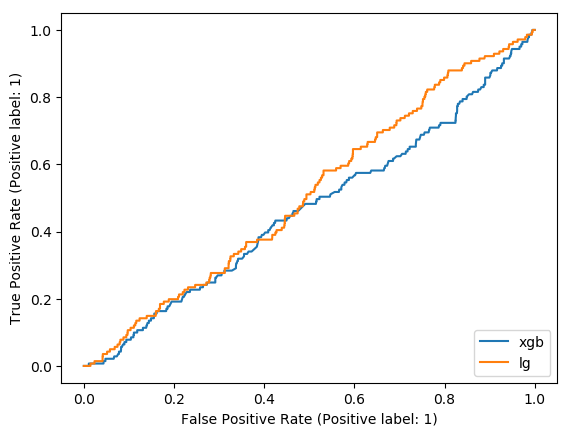

In [38]:
sub_column = ['성별', '일주일운동시간', '수면시간', '채소섭취정도']
train_X = train_X[sub_column]
test_X = test_X[sub_column]

cat_columns = train_X.select_dtypes('object').columns
preprocess = ColumnTransformer([('cat', cat_preprocess, cat_columns)], remainder='passthrough')

pipe_xgb = Pipeline(
    [
        ("preprocess", preprocess),
        ("classifier", xgb.XGBClassifier()) 
    ]
)

pipe_xgb.fit(train_X, train_y)

from sklearn.linear_model import LogisticRegression
pipe_lg = Pipeline(
    [
        ("preprocess", preprocess),
        ("classifier", LogisticRegression()) 
    ]
)

pipe_lg.fit(train_X, train_y)

from sklearn.metrics import plot_roc_curve, auc

fig, ax = plt.subplots()
roc_xgb = plot_roc_curve(pipe_xgb, test_X, test_y, ax = ax, label = 'xgb')
roc_lg = plot_roc_curve(pipe_lg, test_X, test_y, ax = ax, label = 'lg')

plt.show(); 

## 문제 3

별도의 데이터 없음

**평균이 (**$\theta$**)이고 분산이 100인 정규분포 (**$\mathcal{N}(\theta, 100)$**)에서 사전분포로 평균이 100, 분산이 256인 정규분포 (**$\mathcal{N}(100, 256)$**)를 사용합니다. 이때, 관측된 데이터 (**$x = 120$**)일 경우 사후분포의 평균을 구하시오.**

::: callout-note
켤레 사전분포족(conjugate prior family)

베이즈 추론에서 사후분포는 사전분포와 데이터를 통해 얻어진 우도 함수를 결합하여 구해집니다. 켤레 사전분포는 다음과 같은 성질을 가집니다

-   사전분포가 특정한 분포족에 속할 때, 우도 함수와 결합된 사후분포도 동일한 분포족에 속한다.

    분포 표 예시 : <https://en.wikipedia.org/wiki/Conjugate_prior>

이를 통해 계산이 간단해지고, 해석이 직관적이 됩니다.
:::

-   $X_1, \ldots, X_n \sim \mathcal{N}(\mu, \sigma^2)$ with known variance $\sigma^2$

-   $\mu \sim \mathcal{N}(\nu, \tau^2)$

사후 분포

$$
\mu \mid x \sim \mathcal{N}(\mu_p, \sigma_p^2)
$$ $$
\mu_p = \left( \frac{1}{\sigma^2/n} + \tau^{-2} \right)^{-1} \left( \frac{\bar{x}}{\sigma^2/n} + \frac{\nu}{\tau^2} \right)
$$

$$
\sigma_p^2 = \left( \frac{1}{\sigma^2/n} + \tau^{-2} \right)^{-1}
$$

-   $\bar{x}$ : 표본 평균

-   $\nu$ : 사전 분포의 평균

-   $\tau^2$ : 사전 분포의 분산

-   $\sigma^2$ : 데이터 분포의 분산

-   $n$ : 표본 크기

정의된 식에 대입하면 다음과 같이 계산할 수 있음

$$
\mu_{\text{posterior}} = \frac{\frac{100}{256} + \frac{120}{100}}{\frac{1}{256} + \frac{1}{100}} = \frac{1.590625}{0.01390625} \approx 114.4
$$

In [39]:
# 주어진 데이터
mu_prior = 100  # 사전분포의 평균
sigma_prior = 16  # 사전분포의 표준편차 
sigma_prior_squared = sigma_prior ** 2  # 사전분포의 분산

x_observed = 120  # 관측된 데이터
sigma_likelihood = 10  # 우도 함수의 표준편차 
sigma_likelihood_squared = sigma_likelihood ** 2  # 우도 함수의 분산

# 사후분포의 평균 계산
mu_posterior = (mu_prior / sigma_prior_squared + x_observed / sigma_likelihood_squared) / \
               (1 / sigma_prior_squared + 1 / sigma_likelihood_squared)

print(f"사후분포의 평균: {mu_posterior:.2f}")

사후분포의 평균: 114.38


## 문제 4

**Data description**

-   **TV_Ad_Budget** : TV 광고 예산

-   **Radio_Ad_Budget** : 라디오 광고 예산

-   **Newspaper_Ad_Budget** : 신문 광고 예산

-   **Sales** : 판매 수익

In [40]:
df = pd.read_csv('problem4.csv')

1.  **선형 회귀 모델을 적합한 후 통계적 유의성을 검토하시오.**

In [41]:
import pandas as pd
import statsmodels.formula.api as smf

fit = smf.ols('Sales ~ TV_Ad_Budget + Radio_Ad_Budget + Newspaper_Ad_Budget', data=df).fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sun, 06 Jul 2025   Prob (F-statistic):           1.58e-96
Time:                        21:38:09   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               2.9389    

-   모델에 대한 통계적 유의성

$$
\begin{aligned}
&H_0: \beta_1 = \beta_2 = \cdots = \beta_k = 0 \\
&H_1: \text{at least one } \beta_j \neq 0 \text{ for } j = 1, 2, \ldots, k
\end{aligned}
$$

F-검정 결과를 보면 유의수준 5%에서 p-value \< 0.05이므로, 귀무가설을 기각한다. 따라서 회귀모델에서 적어도 하나의 독립변수는 Sales(판매 수익)에 통계적으로 유의미한 영향을 미친다.

-   회귀 계수에 대한 통계적 유의성

$$
\begin{aligned}
&H_0: \beta_j = 0 \\
&H_1: \beta_j \neq 0, \\
\end{aligned}
$$

유의수준 5%에서 TV_Ad_Budget, Radio_Ad_Budget 변수 모두 p-value \< 0.05이므로 귀무가설을 기각한다. 따라서 TV_Ad_Budget**(**TV 광고 예산), Radio_Ad_Budget**(**라디오 광고 예산)은 Sales(판매 수익)에 통계적으로 유의미한 영향을 끼친다.

2.  **변수 선택시에 먼저 제거가 될 변수를 파악하고, 근거를 제시하시오.**

-   Newspaper_Ad_Budget**(신문 광고 예산) 변수는 통계적으로 유의하지 않으므로, 전체 모델에서 모델에서 제거한다.**

In [42]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

full_model = smf.ols('Sales ~ TV_Ad_Budget + Radio_Ad_Budget + Newspaper_Ad_Budget', data=df).fit()

# Newspaper_Ad_Budget을 제거한 모델 적합
reduced_model = smf.ols('Sales ~ TV_Ad_Budget + Radio_Ad_Budget', data=df).fit()

# 두 모델의 ANOVA 비교
anova_results = anova_lm(reduced_model, full_model)
print(anova_results)

   df_resid         ssr  df_diff   ss_diff         F    Pr(>F)
0     197.0  556.913980      0.0       NaN       NaN       NaN
1     196.0  556.825263      1.0  0.088717  0.031228  0.859915


유의수준 5%에서 귀무가설을 기각할 수 없다. 따라서 Newspaper_Ad_Budget는 모델의 설명력에 크게 기여하지 않는다.

-   **분산팽창계수(VIF)를 활용하여 다중공선성을 진단하시오.**

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 다중공선성 진단을 위한 VIF 계산 함수
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(len(df.columns))]
    return vif_data

# 독립 변수만 사용하여 VIF 계산
X = df[['TV_Ad_Budget', 'Radio_Ad_Budget']]
vif_data = calculate_vif(X)
print(vif_data)

           feature       VIF
0     TV_Ad_Budget  2.238085
1  Radio_Ad_Budget  2.238085


두 변수 모두 vif가 2이므로, 다중공선성은 존재하지 않는다.

## 문제 5

회사에서는 3개의 다른 마케팅 캠페인(캠페인 A, 캠페인 B, 캠페인 C)을 실행하여 고객에게 이메일을 발송했습니다. 각 캠페인 후, 고객이 제품을 구매했는지 여부를 기록했습니다. 다음 데이터는 15명의 고객에 대해 각 캠페인에 대한 구매 여부(1: 구매, 0: 미구매)를 나타낸 것입니다.

In [44]:
df = pd.read_csv('problem5.csv')

**각 마케팅 캠페인(A, B, C)의 구매 효과의 차이가 있는지 여부를 검정하시오.**

::: callout-note
-   독립 표본에 대한 범주형 변수 간의 관계 검정 : 카이제곱 검정

-   대응 표본에 대한 범주형 변수 간의 관계 검정 : 코크란 Q 검정(세 그룹 이상일 때)
:::

$$
\begin{aligned}
&H_0 : 마케팅 캠페인은 모두 동일한 구매 효과를 가진다 \\
&H_1 : 세 마케팅 캠페인 중 적어도 하나는 구매 효과의 차이가 존재한다. 
\end{aligned}
$$

In [45]:
from statsmodels.stats.contingency_tables import cochrans_q


# 코크란 Q 검정을 위한 데이터 준비 (고객 ID 제거)
campaign_data = df.drop(columns=['Customer'])

# 코크란 Q 검정 수행
result = cochrans_q(campaign_data)

# 결과 출력
print(f'Q statistic: {result.statistic:.4f}, p-value: {result.pvalue:.4f}')

# 해석
if result.pvalue < 0.05:
    print("세 캠페인 중 적어도 하나는 구매 효과에 차이가 있다.")
else:
    print("세 캠페인의 구매 효과는 통계적으로 유의미한 차이가 없다.")

Q statistic: 0.1818, p-value: 0.9131
세 캠페인의 구매 효과는 통계적으로 유의미한 차이가 없다.


## 문제 6

별도의 데이터 없음

어떤 웹사이트는 매시간 평균 4명의 방문자가 들어옵니다. 이 웹사이트에 대해 다음 질문에 답하시오.

::: callout-note
특정 시간 동안 발생한 사건의 건수는 포아송분포를 따름

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$
:::

1.  **한 시간 동안 방문자가 한 명도 없을 확률을 계산하시오.**

$$
P(X = 0) = \frac{4^0 e^{-4}}{0!} = e^{-4} = 0.0183
$$

In [46]:
from scipy.stats import poisson
lambda_ = 4
prob_0 = poisson.pmf(0, lambda_)
print(f'P(X = 0) = {prob_0:.4f}')

P(X = 0) = 0.0183


2.  **한 시간 동안 방문자가 5명 이상일 확률을 계산하시오.**

$$
\begin{aligned}
&P(X < 5) = P(X = 0) + P(X = 1) + P(X = 2) + P(X = 3) + P(X = 4) = 0.6289 \\
&P(X \geq 5) = 1 - P(X < 5) = 0.3711
\end{aligned}
$$

In [47]:
from scipy.stats import poisson

lambda_ = 4

prob_5_or_more = 1 - poisson.cdf(4, lambda_)
print(f'P(X >= 5) = {prob_5_or_more:.4f}')

P(X >= 5) = 0.3712
